<a href="https://colab.research.google.com/github/EmiiFernandez/actividades_data_sciente_ypf/blob/main/notebook/C20_Notebook-24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

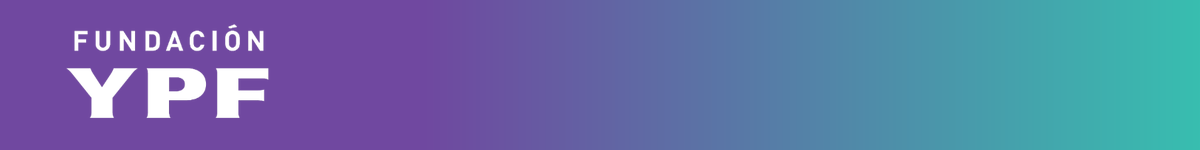

# Fundación YPF - Data Science

## Notebook 24: Repaso y práctica de K-Means

### Índice de partes

* **Parte 0:** Preparación del entorno
* **Parte 1:** Repaso de K-Means con datos sintéticos
* **Parte 2:** Preparación de los datos reales: compradores de Black Friday
* **Parte 3:** Elección del número de clusters
* **Parte 4:** K-Means sobre los compradores e interpretación de los clusters
* **Parte 5:** Estabilidad del algoritmo y límites de K-Means
* **Parte 6:** Ejercicio para las salas de Zoom

## Parte 0: Preparación del entorno

En la clase anterior vimos qué es el aprendizaje no supervisado y cómo funciona **K-Means**. Hoy lo usamos de punta a punta sobre un problema real, y repasamos las decisiones que más afectan el resultado: **escalar las variables**, **elegir k**, **interpretar los clusters** y **conocer los límites del algoritmo**.

**Datasets:**

* `blackfriday.csv`: compras realizadas durante un Black Friday en una tienda minorista. Cada fila es una compra y trae el usuario, algunas características del comprador y el monto. Lo usamos en la parte guiada.
* `venta_autos.csv`: anuncios de autos usados. Lo usamos en el ejercicio de las salas.

**Problema de la parte guiada:** la tienda quiere **segmentar a sus compradores según su comportamiento de compra** para pensar acciones distintas para cada grupo. No hay etiquetas: los grupos los tiene que descubrir el algoritmo.

Antes de ejecutar, subí los archivos `blackfriday.csv` y `venta_autos.csv` al panel de archivos de Colab (ícono de carpeta a la izquierda).

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs, make_moons

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## Parte 1: Repaso de K-Means con datos sintéticos

**Qué hace K-Means:** separa los datos en **k** clusters. Busca k **centroides** (uno por cluster) tal que cada instancia quede lo más cerca posible del centroide de su cluster. El algoritmo repite dos pasos hasta que los centroides no se mueven: asignar cada instancia al centroide más cercano y actualizar cada centroide como el promedio de sus instancias.

Veámoslo en un caso donde sabemos la respuesta: datos generados con tres grupos.

In [ ]:
X_blobs, grupo_real = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=RANDOM_STATE)

kmeans = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_blobs)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)
ax[0].scatter(X_blobs[:, 0], X_blobs[:, 1], color="#7030A0", alpha=0.6)
ax[0].set_title("Datos sin etiquetas")
ax[1].scatter(X_blobs[:, 0], X_blobs[:, 1], c=kmeans.labels_, cmap="tab10", alpha=0.7)
ax[1].scatter(*kmeans.cluster_centers_.T, c="black", marker="X", s=250, edgecolor="white")
ax[1].set_title("Clusters encontrados y centroides")
plt.tight_layout()
plt.show()

print("Inercia:", round(kmeans.inertia_, 1))

La **inercia** es la suma de las distancias al cuadrado entre cada instancia y el centroide de su cluster. Mide qué tan compactos son los clusters: cuanto menor, mejor. La vamos a usar para elegir k.

### 1.1 Por qué hay que escalar

K-Means se basa en **distancias**. Si una variable tiene valores mucho más grandes que las otras, domina el cálculo. Armamos un ejemplo: dos grupos que se distinguen en la variable `x` (valores chicos) y una variable `y` que es puro ruido pero con valores enormes.

In [ ]:
rng = np.random.default_rng(RANDOM_STATE)
n = 200
grupo = np.repeat([0, 1], n // 2)
x = rng.normal(loc=grupo * 3, scale=0.5)      # separa bien a los dos grupos
y = rng.normal(loc=0, scale=100, size=n)      # ruido con escala enorme
X_esc = np.column_stack([x, y])

sin_escalar = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(X_esc)
con_escalar = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(StandardScaler().fit_transform(X_esc))

print("Sin escalar: coincidencia entre cluster y grupo real")
print(pd.crosstab(grupo, sin_escalar.labels_, rownames=["grupo real"], colnames=["cluster"]))
print()
print("Con escalado:")
print(pd.crosstab(grupo, con_escalar.labels_, rownames=["grupo real"], colnames=["cluster"]))

Sin escalar, K-Means corta por la variable de ruido porque es la que más pesa en las distancias. Al escalar, las dos variables aportan por igual y el algoritmo encuentra los grupos reales. **Siempre escalamos antes de usar K-Means** (o cualquier método basado en distancias).

## Parte 2: Preparación de los datos reales: compradores de Black Friday

In [ ]:
if not os.path.exists("blackfriday.csv"):
    from google.colab import files
    files.upload()

bf = pd.read_csv("blackfriday.csv")
print("Filas:", bf.shape[0], "| Columnas:", bf.shape[1])
bf.head()

In [ ]:
(bf.isna().mean() * 100).round(1).sort_values(ascending=False)

Cada fila es **una compra**, pero queremos segmentar **compradores**. Entonces el primer paso es **construir una tabla con una fila por usuario**, resumiendo su comportamiento:

* `compras`: cantidad de compras realizadas.
* `ticket`: monto promedio por compra.
* `categorias`: cantidad de categorías de producto distintas que compró.
* `gasto_total`: monto total gastado (lo usamos para interpretar, no para agrupar).
* `edad`: edad del usuario (tampoco la usamos para agrupar, la miramos al interpretar).

Los valores faltantes de `Purchase` no se suman ni se promedian, así que las funciones de agregación los ignoran. Las variables de perfil (`Gender`, `Age`, `Occupation`) tienen faltantes distribuidos entre las compras, pero como cada usuario tiene muchas compras, tomamos la mediana de la edad y no perdemos usuarios.

In [ ]:
usuarios = bf.groupby("User_ID").agg(
    compras=("Purchase", "count"),
    gasto_total=("Purchase", "sum"),
    ticket=("Purchase", "mean"),
    categorias=("Product_Category_1", "nunique"),
    edad=("Age", "median"),
)

print("Usuarios:", len(usuarios))
usuarios.describe().round(1)

### 2.1 Distribución y transformación

Miramos la forma de cada variable que vamos a usar para agrupar.

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, col in zip(ax, ["compras", "ticket", "categorias"]):
    sns.histplot(usuarios[col], bins=30, kde=True, ax=a, color="#7030A0")
    a.set_title(f"Distribución de {col}")
plt.tight_layout()
plt.show()

`compras` tiene una **cola larga a la derecha**: la mayoría compra pocas veces y unos pocos usuarios compran cientos de veces. Esos valores extremos tirarían de los centroides. Aplicamos una **transformación logarítmica** para comprimir la cola.

También revisamos si dos variables dicen casi lo mismo.

In [ ]:
usuarios["log_compras"] = np.log1p(usuarios["compras"])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(usuarios["log_compras"], bins=30, kde=True, ax=ax[0], color="#30BEAA")
ax[0].set_title("Compras con transformación logarítmica")
sns.heatmap(usuarios[["compras", "gasto_total", "ticket", "categorias"]].corr(), annot=True, fmt=".2f",
            cmap="Purples", ax=ax[1])
ax[1].set_title("Correlación entre variables")
plt.tight_layout()
plt.show()

`compras` y `gasto_total` están casi perfectamente correlacionadas (0.98): quien compra más veces gasta más en total. Usar las dos sería contar dos veces la misma información, así que **agrupamos con `log_compras`, `ticket` y `categorias`**, y dejamos `gasto_total` y `edad` para interpretar los clusters.

In [ ]:
variables = ["log_compras", "ticket", "categorias"]
escalador = StandardScaler()
X = escalador.fit_transform(usuarios[variables])

pd.DataFrame(X, columns=variables).describe().loc[["mean", "std"]].round(2)

## Parte 3: Elección del número de clusters

K-Means necesita que le indiquemos **k** de antemano. Usamos el **método del codo**: entrenamos con distintos valores de k y graficamos la inercia. Siempre baja al aumentar k, pero buscamos el punto desde el cual la mejora deja de ser grande.

In [ ]:
valores_k = range(1, 11)
inercias = [KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X).inertia_ for k in valores_k]

plt.figure(figsize=(8, 4.5))
plt.plot(valores_k, inercias, "o-", color="#7030A0")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.xticks(list(valores_k))
plt.tight_layout()
plt.show()

Acá **no hay un codo marcado**: la curva baja de forma gradual. Es lo más común con datos reales. Cuando el gráfico no decide, entran otros criterios:

* **Interpretabilidad:** ¿podemos describir cada grupo con una frase clara?
* **Utilidad:** ¿la empresa puede actuar de forma distinta con cada grupo? Pocos grupos son más manejables.
* **Tamaño:** evitamos clusters demasiado chicos para ser relevantes.

Comparamos los perfiles con k = 3 y con k = 4.

In [ ]:
for k in [3, 4]:
    etiquetas = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(X)
    perfil = usuarios.assign(cluster=etiquetas).groupby("cluster")[["compras", "ticket", "categorias"]].mean().round(1)
    perfil["usuarios"] = pd.Series(etiquetas).value_counts().sort_index()
    print(f"k = {k}")
    display(perfil)

Con k = 3 los usuarios de pocas compras se separan por ticket (bajo y alto) y queda un único grupo de compradores frecuentes. Con k = 4 ese grupo frecuente se divide en dos niveles (frecuentes y muy frecuentes), una distinción útil para la empresa porque los más frecuentes suelen concentrar gran parte de las ventas. Elegimos **k = 4**. En las próximas clases vemos métricas para validar esta decisión con más rigor.

## Parte 4: K-Means sobre los compradores e interpretación de los clusters

In [ ]:
kmeans = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit(X)
usuarios["cluster"] = kmeans.labels_

print("Inercia:", round(kmeans.inertia_, 1))
usuarios["cluster"].value_counts().sort_index()

### 4.1 Perfil de cada cluster

Describimos cada grupo con los promedios en **unidades originales** (no con los datos escalados), e incluimos las variables que no se usaron para agrupar.

In [ ]:
perfil = usuarios.groupby("cluster").agg(
    usuarios=("compras", "size"),
    compras=("compras", "mean"),
    ticket=("ticket", "mean"),
    categorias=("categorias", "mean"),
    gasto_total=("gasto_total", "mean"),
    edad=("edad", "mean"),
).round(1)

perfil["% de usuarios"] = (perfil["usuarios"] / perfil["usuarios"].sum() * 100).round(1)
perfil["% del gasto total"] = (usuarios.groupby("cluster")["gasto_total"].sum() / usuarios["gasto_total"].sum() * 100).round(1)
perfil

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=usuarios, x="compras", y="ticket", hue="cluster", palette="tab10", alpha=0.6, s=25, ax=ax[0])
ax[0].set_xscale("log")
ax[0].set_title("Compras (escala logarítmica) vs ticket promedio")
sns.scatterplot(data=usuarios, x="compras", y="categorias", hue="cluster", palette="tab10", alpha=0.6, s=25, ax=ax[1])
ax[1].set_xscale("log")
ax[1].set_title("Compras (escala logarítmica) vs categorías distintas")
plt.tight_layout()
plt.show()

**Cómo leer los resultados:**

* Buscá en cada fila de la tabla qué distingue a ese grupo de los demás y **poneles un nombre** (por ejemplo, compradores ocasionales, frecuentes, de ticket alto).
* Comparar `% de usuarios` con `% del gasto total` muestra cuánto pesa cada grupo en la facturación. Un grupo chico puede concentrar buena parte de las ventas.
* La edad **no se usó** para agrupar. Si los grupos casi no difieren en edad, significa que el comportamiento de compra no depende de ella en estos datos.

Ese análisis, y no el número de cluster, es el entregable de una segmentación.

## Parte 5: Estabilidad del algoritmo y límites de K-Means

### 5.1 La inicialización importa

K-Means parte de centroides elegidos al azar y puede quedar atrapado en una solución peor (un **mínimo local**). Lo vemos con datos sintéticos de 6 grupos bien separados, haciendo un solo intento por semilla (`n_init=1`) con inicialización al azar.

In [ ]:
X_seis, _ = make_blobs(n_samples=600, centers=6, cluster_std=0.8, random_state=7)

resultados = []
for semilla in range(10):
    km = KMeans(n_clusters=6, init="random", n_init=1, random_state=semilla).fit(X_seis)
    resultados.append({"semilla": semilla, "inercia": km.inertia_})
resultados = pd.DataFrame(resultados)

mejor = KMeans(n_clusters=6, n_init=10, random_state=RANDOM_STATE).fit(X_seis)
print("Inercia con n_init=10 y k-means++:", round(mejor.inertia_, 1))
resultados.round(1)

Algunas semillas llegan a la mejor inercia y otras quedan en soluciones mucho peores: dos centroides en un mismo grupo real y un grupo real sin centroide. Por eso scikit-learn usa por defecto una inicialización más cuidadosa (`k-means++`) y repetimos el entrenamiento varias veces con `n_init`, quedándonos con la mejor solución. En los datos de Black Friday, que son más "suaves", las distintas semillas dan soluciones casi idénticas, pero no podemos asegurarlo de antemano.

### 5.2 K-Means asume clusters esféricos

K-Means asigna cada punto al centroide más cercano, así que genera clusters con forma de **esfera** y tamaños parecidos. Veamos qué pasa cuando los grupos tienen otra forma.

In [ ]:
X_lunas, _ = make_moons(n_samples=300, noise=0.06, random_state=RANDOM_STATE)
km_lunas = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(X_lunas)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)
ax[0].scatter(X_lunas[:, 0], X_lunas[:, 1], color="#7030A0", alpha=0.6)
ax[0].set_title("Dos grupos con forma de media luna")
ax[1].scatter(X_lunas[:, 0], X_lunas[:, 1], c=km_lunas.labels_, cmap="tab10", alpha=0.7)
ax[1].scatter(*km_lunas.cluster_centers_.T, c="black", marker="X", s=250, edgecolor="white")
ax[1].set_title("K-Means con k = 2")
plt.tight_layout()
plt.show()

A simple vista hay dos grupos claros, pero K-Means corta la figura por la mitad porque solo sabe armar regiones compactas alrededor de un centroide. Tampoco maneja bien los **outliers**, que desplazan los centroides. En la próxima clase vemos **DBSCAN**, un algoritmo basado en densidad que resuelve estos casos.

**Resumen de buenas prácticas con K-Means:**

* Escalar las variables antes de agrupar.
* Revisar la forma de las variables y transformar las que tienen colas largas.
* Evitar variables redundantes.
* Elegir k combinando el codo con la interpretabilidad.
* Usar `n_init` mayor a 1 y fijar `random_state` para que el resultado sea reproducible.
* Interpretar los clusters en unidades originales.

## Parte 6: Ejercicio para las salas de Zoom

**Dataset:** `venta_autos.csv`. Son 50.000 anuncios de autos usados publicados en un sitio de compra y venta. Las columnas más útiles para este ejercicio son `price` (precio en euros), `yearOfRegistration` (año de patentamiento), `powerPS` (potencia en caballos de fuerza) y `kilometer` (kilómetros recorridos).

**Objetivo:** descubrir **tipos de autos** en el mercado de usados con K-Means. Nadie etiquetó los anuncios: queremos ver qué segmentos aparecen.

**Tiempo:** 50 minutos. Al final, cada sala comparte sus conclusiones.

**Consigna:**

1. **Exploración.** Revisá las estadísticas de `price`, `yearOfRegistration`, `powerPS` y `kilometer`. Hay valores imposibles o poco creíbles en varias de estas columnas. Identificalos y decidí qué hacer con ellos, justificando los límites que elegís.
2. **Nueva variable.** Un auto se describe mejor por su **antigüedad** que por el año de patentamiento. Creá la variable `antiguedad` (el año de los datos es 2016).
3. **Distribución.** Graficá las variables que vas a usar. ¿Alguna tiene cola larga? ¿Conviene transformarla?
4. **Escalado.** Escalá las variables elegidas.
5. **Elección de k.** Calculá la inercia para distintos valores de k y graficala. ¿Hay un codo claro? Si no lo hay, ¿qué otros criterios usás?
6. **K-Means.** Entrená el modelo con el k elegido.
7. **Interpretación.** Describí cada cluster con los promedios en unidades originales y poneles un nombre. Mirá además variables que **no usaste** para agrupar, como `vehicleType` o `brand`.
8. **Robustez.** Repetí el entrenamiento con otra semilla y con `n_init=1`. ¿Los grupos se mantienen?

**Preguntas para la puesta en común:**

* ¿Qué valores extremos encontraron y qué criterio usaron para descartarlos?
* ¿Qué pasa con los clusters si no escalan las variables?
* ¿Qué segmentos de autos aparecieron? ¿Tienen sentido de negocio?
* ¿Qué decisión de preparación influyó más en el resultado?

In [ ]:
# Cargamos el dataset del ejercicio
if not os.path.exists("venta_autos.csv"):
    from google.colab import files
    files.upload()

autos = pd.read_csv("venta_autos.csv")
print("Filas:", autos.shape[0], "| Columnas:", autos.shape[1])
autos.head()

In [ ]:
# 1. Exploración y tratamiento de valores extremos
# COMPLETAR

In [ ]:
# 2 y 3. Nueva variable y distribución de las variables
# COMPLETAR

In [ ]:
# 4. Escalado
# COMPLETAR

In [ ]:
# 5. Elección de k con el método del codo
# COMPLETAR

In [ ]:
# 6 y 7. K-Means e interpretación de los clusters
# COMPLETAR

In [ ]:
# 8. Robustez del resultado
# COMPLETAR